Cassio is imported so that we can access the astradb using cassandra because this library helps to use the astradb using cassandera

In [73]:
!pip install langchain langgraph cassio langchain_community tiktoken langchainhub chromadb langchain_huggingface langchain_text_splitters langchain_groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 6.0 MB/s eta 0:00:00


In [148]:
import cassio
from google.colab import userdata # Corrected typo from 'collab' to 'colab'

# connection to astradb
# Retrieve secrets from Colab's secrets manager
astra_db_app_token = userdata.get('astra_token')
astra_DB_id = userdata.get('astra_id')

cassio.init(token=astra_db_app_token, database_id=astra_DB_id)

In [2]:
from langchain_community.document_loaders.onedrive_file import CHUNK_SIZE
  # chromadb will not be used because we are already using astrdb
  # reading the website and converting those text into vectors and storing into vectordb
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import WebBaseLoader


# Docs to index

urls = [
    "https://lilianweng.github.io/posts/2023-06-23-agent/",
    "https://lilianweng.github.io/posts/2023-03-15-prompt-engineering/",
    "https://lilianweng.github.io/posts/2023-10-25-adv-attack-llm/"
]

# load the url
docs = [WebBaseLoader(urls).load() for url in urls]
doc_list = [item for sublist in docs for item in sublist]
text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(chunk_size = 500, chunk_overlap = 0)
texts = text_splitter.split_documents(doc_list)

In [12]:
print(doc_list)

[Document(metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/', 'title': "LLM Powered Autonomous Agents | Lil'Log", 'description': 'Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistakes and refine them for future steps, thereby improving the quality of final resu

In [13]:
doc_list

[Document(metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/', 'title': "LLM Powered Autonomous Agents | Lil'Log", 'description': 'Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistakes and refine them for future steps, thereby improving the quality of final resu

In [15]:
# using embeddings to convert this texts to vectors
from langchain_huggingface import HuggingFaceEmbeddings
embeddings = HuggingFaceEmbeddings(model_name = 'all-MiniLM-L6-v2')

In [16]:
# storing vectors into vectordb - astradb
from langchain_community.vectorstores.cassandra import Cassandra
astra_vectordb = Cassandra(embedding=embeddings, table_name = 'mini_demo', session = None, keyspace = None)

In [45]:
astra_vectordb.add_documents(texts)

['87ec05a8814f43749164d51866d7302b',
 '1136ccdeaa0a445f98e3e26d5076e4c0',
 '0f3d20038b494ab18671506f7ac9d5ff',
 '67a1f21141df4d659a8d4cdffc9adbf9',
 '4a1f10301a6546c785754770a2e012e0',
 '765fb340acda4f6dbe74f5fed02dc750',
 '13b93ab88c144843ac09e814a406bfc4',
 'fedf80a2661d416199827be0445d0b65',
 '3364514da55045e28f90e6d05381697f',
 '7fdf4f82c3754b969348e5c4b1f8e119',
 '701a48252af747458fe5881bc23f4bf4',
 'e7d8c46420a24052ac9d8e2e3d6840f2',
 '29b4a0dad6574bab837495fbc82f4005',
 'a27726c71b2145cc8abd4a2094c7bf97',
 '75b130177c484adc840dc027d0563ac0',
 '4bb9ed90ea8f455c8bb8d4235e16920b',
 '895fd9ededfa49de82465767bbd93a2a',
 '5b01244345254c59a8c53e159f92fd04',
 '0daded3b8acc4dc9a12575e2a10905fe',
 '5c550a11926d4ec9ba91b0bce516c924',
 '8a473f265e39449c83eba1866e78a4fa',
 'e8677eb72def4589b50b21637b3f7645',
 'accaca51e50f401991072b237cb5780f',
 'ccb0ed059b3f43e7843922ab3af74b31',
 '862941a2672a457299b2c5afad894976',
 '7ca9530df61b487ca4cbd24d58b8c2d7',
 '6a10c3f0bed747cd9b5b01e21369990a',
 

In [17]:
# adding retriver so that i can ask any question
retriever=astra_vectordb.as_retriever()
retriever.invoke("What is agent")

[Document(id='f0034dcc6afb455fbbd252ebfc0e58ae', metadata={'description': 'Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistakes and refine them for future steps, thereby improving the quality of final results.\n\n\nMemory\n\nShort-term memory: I would consider all the in-context lear

In [23]:
# Langgraph application - creating router funtion
from typing import Literal # using this library for the hints you get for the typing.
from langchain_core.prompts import ChatPromptTemplate # to define template
from pydantic import BaseModel, Field # basemodel will be required in router.

In [19]:
# data model
class routequery(BaseModel):
  """ Route a query to the most relevant datasource """
  datasource: Literal["vectorstore", "Wiki_search"] = Field(
      description="The datasource to route the query to wikipedia or vectorstore")


In [91]:
# using Groq as LLM
from langchain_groq import ChatGroq
from google.colab import userdata # with this you can use the saved api
import os  # for setting up the environment

api = userdata.get('groq_api_key')
# ChatGroq usually expects GROQ_API_KEY environment variable
os.environ['GROQ_API_KEY'] = api

In [97]:
# initialized the LLM model to use for the query
llm = ChatGroq(model = 'openai/gpt-oss-120b') # Using 'llama3-8b-8192' as a common Groq model name.
llm

ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x7dd756630560>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x7dd75543a570>, model_name='openai/gpt-oss-120b', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [99]:
# created Routequery so that it can tell that whether it wikisearch or vectordb
structured_llm_router = llm.with_structured_output(routequery)

In [100]:
# using prompt for the LLM
system = """ You are an expert at routing a user question to vectorsb or wikisearch.
The vectorstore contains documents related to agents, prompt engineering and adversarial
attacks. Use the vectostore for questions on these topics. Otherwise, use
wiki search. """

route_prompt = ChatPromptTemplate.from_messages(
   [
      ("system", system),   # giving the instructions defined to the LLm
      ("human", "{question}")
  ] # user question is going to go.
)
question_router = route_prompt | structured_llm_router

In [101]:
# testing the code for the queries entered.
print(question_router.invoke(
    {
        "question": "What is agent"
    }
))

datasource='vectorstore'


In [102]:
# testing the code for wikisearch whether the router is sending the queries for the wikisearch or not
print(question_router.invoke(
    {
        "question": "Who is shahruk khan"
    }
))

datasource='Wiki_search'


In [103]:
# create a wiki pedia search.
# langchain framework has various 3rd party which you can install and get through it.

!pip install arxiv wikipedia

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.5/81.5 kB 5.9 MB/s eta 0:00:00
  Created wheel for wikipedia: filename=wikipedia-1.4.0-py3-none-any.whl size=11678 sha256=b38a954ba8415a6149f251e045377f0edb366e923a9f3f6e213452de330ee3f2
  Stored in directory: /root/.cache/pip/wheels/63/47/7c/a9688349aa74d228ce0a9023229c6c0ac52ca2a40fe87679b8
  Created wheel for sgmllib3k: filename=sgmllib3k-1.0.0-py3-none-any.whl size=6046 sha256=3b650e4751d49ea81893c74a0c6a2be34798a6c1fdc0eca423286f6e797e2a9e
  Stored in directory: /root/.cache/pip/wheels/03/f5/1a/23761066dac1d0e8e683e5fdb27e12de53209d05a4a37e6246
Successfully built wikipedia sgmllib3k


In [109]:
# creatiing wikipedia so that the queries can be answered
# top_k_results
from langchain_community.utilities import WikipediaAPIWrapper
from langchain_community.tools import WikipediaQueryRun
api_wrapper = WikipediaAPIWrapper(top_k_results=1,doc_content_chars_max=200)
wiki = WikipediaQueryRun(api_wrapper=api_wrapper) # api_wrapper will help to provide the result on the basis of the LLm installed.

In [113]:
wiki.run("tell me about indian actor")

'Page: Feroz Khan (actor)\nSummary: Feroz Khan (born Zulfiqar Ali Shah Khan; 25 September 1939 — 27 April 2009) was an Indian actor, film editor, producer and director best known for his work in Indian '

In [137]:
# Ai agent application using langgraph
# we have created all the elements but need to connect nodes all the edges so that it can turn into agent
# We are going to create a graph
from typing import List
from typing_extensions import TypedDict

class Graphstate(TypedDict):
  """
  represents all of our graph

  Attributes :
  question : question
  generation : lLm generation
  documents : list of documents
  route_choice: str # New field to store the router's decision
  """
  question: str
  generation: str
  documents: list[str]
  route_choice: str
  # creating this class has defined the data type of all the attributes with the help of typedict

In [119]:
from langchain_core.documents import Document

def retrieve(state):
  """
  Retrieve documents based on a question.
  """
  question = state["question"]
  documents = retriever.invoke(question)
  print("--retrieve---")
  questions=state["question"]

  ## retrieval
  documents = retriever.invoke(question)
  return{"Documents":documents,"question":question}

In [125]:
from langchain_core.documents import Document
def Wiki_search(state):
  """
  wiki search based on the question asked.
  """
  question = state["question"]
  documents = retriever.invoke(question)
  print("--wikipedia---")
  questions=state["question"]

  ## wiki-search
  docs = wiki.invoke(question)
  wiki_results = docs
  wiki_results = Document(page_content=wiki_results)

  return{"Documents":documents,"question":question}

In [138]:
# creating functions for the router as well
### Edges ###

# This function will now act as the 'action' for our dedicated router node.
# It will store its decision in the state.
def router_node_action(state):
    """
    Node action to route question to wiki search or RAG.
    Updates the state with the chosen route.
    """
    print("---ROUTE QUESTION (from router node) ---")
    question = state["question"]
    source = question_router.invoke({"question": question})
    if source.datasource == "Wiki_search": # Assuming 'Wiki_search' is the correct literal from routequery
        print("---ROUTE QUESTION TO Wiki SEARCH---")
        state["route_choice"] = "wiki_search"
    elif source.datasource == "vectorstore":
        print("---ROUTE QUESTION TO RAG---")
        state["route_choice"] = "vectorstore"
    else:
        # Default route if nothing matches (e.g., fallback to RAG)
        print("---ROUTE QUESTION TO RAG (default) ---")
        state["route_choice"] = "vectorstore"
    return state

In [140]:
# creating entire langgraph state
from langgraph.graph import END, StateGraph, START

workflow = StateGraph(Graphstate)

# define the nodes
workflow.add_node("router", router_node_action) # Add the router as an explicit node
workflow.add_node("wiki_search", Wiki_search)
workflow.add_node("retrieve", retrieve)

# build the graph
workflow.add_edge(START, "router") # Always start by going to the router node

# Now, conditional edges from the 'router' node
workflow.add_conditional_edges(
    "router",
    lambda state: state["route_choice"], # Condition function checks the 'route_choice' in the state
    {
        "wiki_search":"wiki_search",
        "vectorstore":"retrieve"
    }
)
workflow.add_edge("retrieve",END)
workflow.add_edge("wiki_search",END)

# compile
app = workflow.compile()

In [133]:
!pip install Ipython

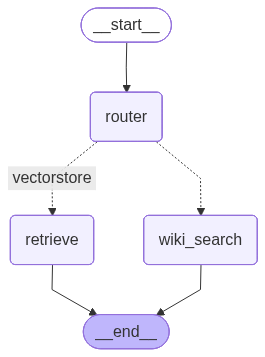

In [141]:
# Display the graph using ipython.
from IPython.display import Image, display

try:
  display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
  pass